In [1]:
import pandas as pd
from pathlib import Path
import os

In [3]:
# Define our data paths based on your folder structure
data_dir = Path("../data/raw/CSV Files")
train_test_dir = data_dir / "Training and Testing Sets"

print("--- RAW DATA FILES ---")
raw_files = list(data_dir.glob("UNSW-NB15_[1-4].csv"))
for file in raw_files:
    size_mb = os.path.getsize(file) / (1024 * 1024)
    # Read just the first 5 rows to get the shape without loading the whole file
    df_preview = pd.read_csv(file, header=None, nrows=5) 
    print(f"{file.name}: {size_mb:.2f} MB | Columns: {df_preview.shape[1]}")

print("\n--- PRE-SPLIT DATA FILES ---")
split_files = list(train_test_dir.glob("*.csv"))
for file in split_files:
    size_mb = os.path.getsize(file) / (1024 * 1024)
    df_preview = pd.read_csv(file, nrows=5)
    print(f"{file.name}: {size_mb:.2f} MB | Columns: {df_preview.shape[1]}")

print("\n--- METADATA FILES ---")
features_file = data_dir / "NUSW-NB15_features.csv"
if features_file.exists():
    df_features = pd.read_csv(features_file, encoding='cp1252') # Often needs specific encoding
    print(f"Features metadata loaded. Found {len(df_features)} feature descriptions.")

--- RAW DATA FILES ---
UNSW-NB15_1.csv: 161.15 MB | Columns: 49
UNSW-NB15_2.csv: 157.57 MB | Columns: 49
UNSW-NB15_3.csv: 147.43 MB | Columns: 49
UNSW-NB15_4.csv: 93.07 MB | Columns: 49

--- PRE-SPLIT DATA FILES ---
UNSW_NB15_testing-set.csv: 14.67 MB | Columns: 45
UNSW_NB15_training-set.csv: 30.80 MB | Columns: 45

--- METADATA FILES ---
Features metadata loaded. Found 49 feature descriptions.


# DATA STRATEGY & LOADING

In [5]:
# Load the official pre-split datasets
train_file = train_test_dir / "UNSW_NB15_training-set.csv"
test_file = train_test_dir / "UNSW_NB15_testing-set.csv"
df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

In [6]:
print("\n--- DATASET SHAPES ---")
print(f"Training Data: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns")
print(f"Testing Data:  {df_test.shape[0]:,} rows, {df_test.shape[1]} columns")


--- DATASET SHAPES ---
Training Data: 175,341 rows, 45 columns
Testing Data:  82,332 rows, 45 columns


In [7]:
print("\n--- MISSING VALUES (NaNs) ---")
train_missing = df_train.isna().sum().sum()
test_missing = df_test.isna().sum().sum()
print(f"Total missing values in Train: {train_missing}")
print(f"Total missing values in Test:  {test_missing}")


--- MISSING VALUES (NaNs) ---
Total missing values in Train: 0
Total missing values in Test:  0


In [8]:
print("\n--- TARGET VARIABLES ---")
print("Train labels (0=Normal, 1=Attack):")
print(df_train['label'].value_counts(normalize=True) * 100)

print("\nTrain Attack Categories:")
print(df_train['attack_cat'].value_counts())


--- TARGET VARIABLES ---
Train labels (0=Normal, 1=Attack):
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64

Train Attack Categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


# DATA CLEANING & VALIDATION

In [9]:
import numpy as np

## DUPLICATE CHECK

In [10]:
train_dupes = df_train.duplicated().sum()
test_dupes = df_test.duplicated().sum()
print(f"Exact duplicates in Train: {train_dupes}")
print(f"Exact duplicates in Test:  {test_dupes}")

# Remove duplicates from training data (but NOT test data, to preserve the benchmark)
df_train = df_train.drop_duplicates()
print(f"Train shape after dropping duplicates: {df_train.shape}")

Exact duplicates in Train: 0
Exact duplicates in Test:  0
Train shape after dropping duplicates: (175341, 45)


## HIDDEN NULLS ('-') CHECK

In [12]:
# Let's look at the 'service' column
print("Top 5 categories in 'service' before cleaning:")
print(df_train['service'].value_counts().head(5))

Top 5 categories in 'service' before cleaning:
service
None        94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
Name: count, dtype: int64


In [13]:
# Replace '-' with 'None' (which is more descriptive for an unknown service)
df_train['service'] = df_train['service'].replace('-', 'None')
df_test['service'] = df_test['service'].replace('-', 'None')

print("\nTop 5 categories in 'service' after cleaning:")
print(df_train['service'].value_counts().head(5))


Top 5 categories in 'service' after cleaning:
service
None        94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
Name: count, dtype: int64


## INFINITE VALUES CHECK

In [14]:
# Identify numerical columns
num_cols = df_train.select_dtypes(include=[np.number]).columns

# Check for infinity
train_inf = np.isinf(df_train[num_cols]).values.sum()
print(f"Total infinite values in Train: {train_inf}")

Total infinite values in Train: 0


# DATA LEAKAGE AUDIT & ID REMOVAL

## ID COLUMN REMOVAL

In [15]:
# Check if 'id' exists and drop it
if 'id' in df_train.columns:
    df_train = df_train.drop(columns=['id'])
    df_test = df_test.drop(columns=['id'])
    print("Dropped 'id' column from both Train and Test to prevent data leakage.")
else:
    print("'id' column not found. It may have been dropped already.")

Dropped 'id' column from both Train and Test to prevent data leakage.


## TRUE DUPLICATE CHECK

In [16]:
# Now that 'id' is gone, let's see how many rows are ACTUALLY identical
train_dupes_real = df_train.duplicated().sum()
print(f"REAL exact duplicates in Train (without ID): {train_dupes_real}")

# Drop the real duplicates from the training set
if train_dupes_real > 0:
    df_train = df_train.drop_duplicates()
    print(f"Train shape after dropping REAL duplicates: {df_train.shape}")

REAL exact duplicates in Train (without ID): 67601
Train shape after dropping REAL duplicates: (107740, 44)


# EXPLORATORY DATA ANALYSIS (EDA)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# 1. Checkpoint our cleaned data
df_train.to_csv('../data/processed/cleaned_train.csv', index=False)
df_test.to_csv('../data/processed/cleaned_test.csv', index=False)
print("Saved cleaned datasets to data/processed/")

# Set plot style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

Saved cleaned datasets to data/processed/


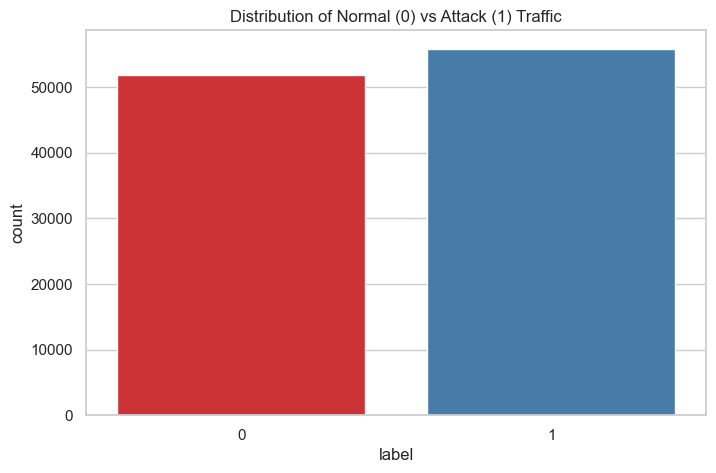

In [27]:
# 2. Binary Target Distribution 
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='label', hue='label', palette='Set1', legend=False)
plt.title('Distribution of Normal (0) vs Attack (1) Traffic')
plt.show()

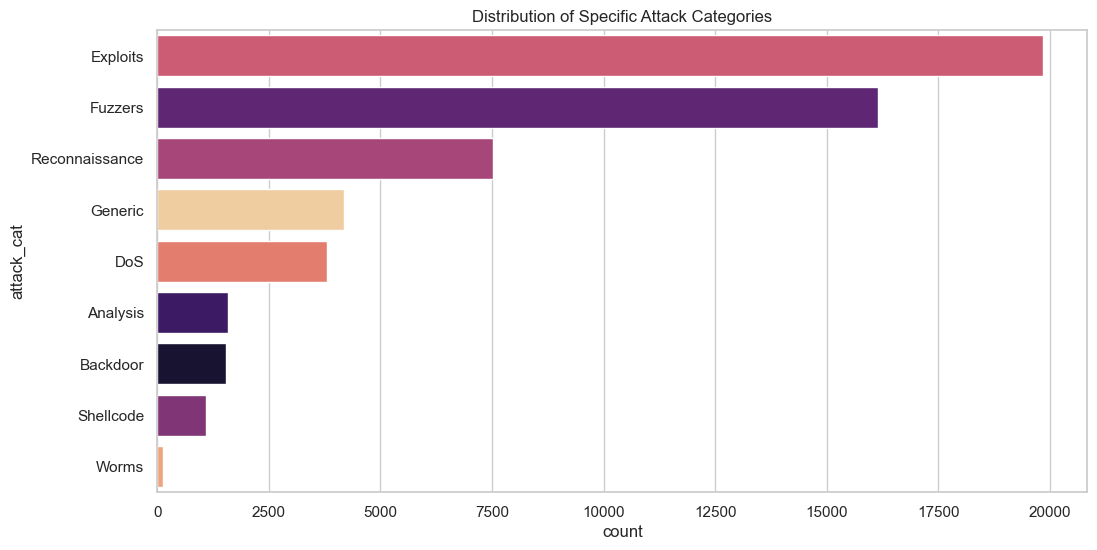

In [28]:
# 3. Multiclass Target Distribution 
plt.figure(figsize=(12, 6))
attacks_only = df_train[df_train['label'] == 1]
sns.countplot(data=attacks_only, y='attack_cat', hue='attack_cat', 
              order=attacks_only['attack_cat'].value_counts().index, 
              palette='magma', legend=False)
plt.title('Distribution of Specific Attack Categories')
plt.show()

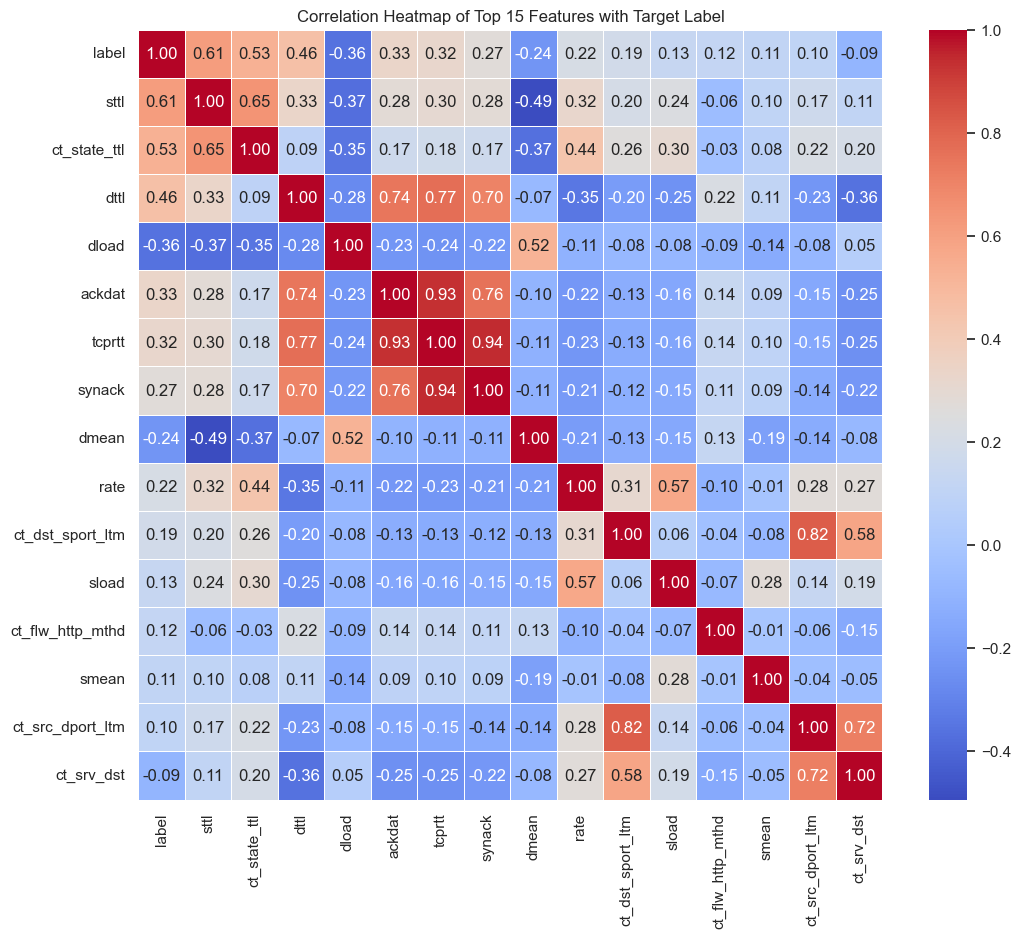

In [26]:
# 4. Correlation Heatmap
# Select only numerical columns
num_cols = df_train.select_dtypes(include=[np.number])
# Calculate the correlation matrix
corr_matrix = num_cols.corr()
# Find the 15 features most correlated with the 'label'
top_corr_features = corr_matrix['label'].abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(12, 10))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Top 15 Features with Target Label')
plt.show()

# OUTLIER ANALYSIS & FEATURE ENGINEERING

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

## SEPARATING FEATURES AND TARGET

In [30]:
# Drop the labels from X
X_train = df_train.drop(columns=['label', 'attack_cat'])
y_train_bin = df_train['label']
y_train_multi = df_train['attack_cat']

X_test = df_test.drop(columns=['label', 'attack_cat'])
y_test_bin = df_test['label']
y_test_multi = df_test['attack_cat']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (107740, 42)
X_test shape:  (82332, 42)


## BUILDING THE PREPROCESSING PIPELINE

In [31]:
# Identify column types
cat_cols = ['proto', 'service', 'state']
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define the transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

print("Fitting preprocessor on training data ONLY...")
X_train_processed = preprocessor.fit_transform(X_train)

print("Applying the learned transformation to test data...")
X_test_processed = preprocessor.transform(X_test)

Fitting preprocessor on training data ONLY...
Applying the learned transformation to test data...


In [33]:
# Convert the Numpy arrays back to Pandas DataFrames so we can see the new column names
feature_names = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

## FEATURE ENGINEERING RESULTS

In [35]:
print(f"Original feature count:  {len(num_cols) + len(cat_cols)}")
print(f"Processed feature count: {X_train_df.shape[1]}")

Original feature count:  42
Processed feature count: 194


In [37]:
print("First 3 rows of processed training data:")
display(X_train_df.head(3))

First 3 rows of processed training data:


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,service_ssl,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no
0,-0.223580,-0.139493,-0.190846,-0.060940,-0.131903,-0.331102,1.010875,1.141228,-0.234937,-0.358601,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.127877,-0.093361,0.058156,-0.058802,0.102349,-0.331064,-0.752046,1.123989,-0.234965,-0.194330,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.048383,-0.127960,-0.102963,-0.060464,-0.059044,-0.331616,-0.752046,1.123989,-0.234997,-0.341203,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# MUTUAL INFORMATION FEATURE SELECTION

In [38]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

## CALCULATING MUTUAL INFORMATION

In [39]:
# Configure SelectKBest to keep the top 40 features
mi_selector = SelectKBest(score_func=mutual_info_classif, k=40)

print("Fitting MI selector on training data... (This may take 1-2 minutes, please wait)")
# Fit using the binary target (Normal vs Attack)
X_train_selected = mi_selector.fit_transform(X_train_df, y_train_bin)

print("Applying feature selection to test data...")
X_test_selected = mi_selector.transform(X_test_df)

# Retrieve the names of the columns that survived the cut
selected_mask = mi_selector.get_support()
selected_features = X_train_df.columns[selected_mask]

# Rebuild Pandas DataFrames with the selected features
X_train_sel_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_sel_df = pd.DataFrame(X_test_selected, columns=selected_features)

print(f"\nSuccess! Reduced feature count from {X_train_df.shape[1]} down to {X_train_sel_df.shape[1]}.")

Fitting MI selector on training data... (This may take 1-2 minutes, please wait)
Applying feature selection to test data...

Success! Reduced feature count from 194 down to 40.


## TOP 15 PREDICTIVE FEATURES

Top 15 Features and their MI Scores:
sbytes          0.461199
dbytes          0.419024
sttl            0.406807
dttl            0.395149
ct_state_ttl    0.388679
dmean           0.332279
rate            0.313789
smean           0.302282
dinpkt          0.301853
tcprtt          0.286225
dur             0.285453
synack          0.282888
ackdat          0.280155
dpkts           0.272372
dload           0.267711
dtype: float64


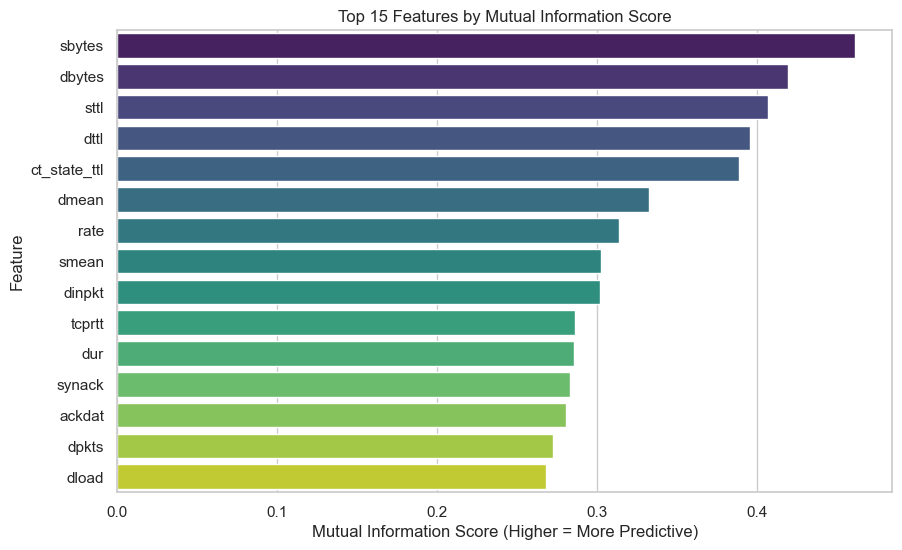

In [41]:
# Map the MI scores back to the original feature names
mi_scores = pd.Series(mi_selector.scores_, index=X_train_df.columns)
mi_scores_sorted = mi_scores.sort_values(ascending=False)

print("Top 15 Features and their MI Scores:")
print(mi_scores_sorted.head(15))

# Visualize the top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_sorted.head(15).values, 
            y=mi_scores_sorted.head(15).index, 
            hue=mi_scores_sorted.head(15).index,
            palette='viridis', 
            legend=False)
plt.title("Top 15 Features by Mutual Information Score")
plt.xlabel("Mutual Information Score (Higher = More Predictive)")
plt.ylabel("Feature")
plt.show()

# CLASS IMBALANCE & TRAIN/VALIDATION STRATEGY

In [42]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

## CREATING VALIDATION SET

In [44]:
# Split the current training data into Train (80%) and Validation (20%)
# 'stratify=y_train_multi' ensures the 80/20 split maintains the exact same ratio of attacks
X_train_final, X_val, y_train_multi_final, y_val_multi = train_test_split(
    X_train_sel_df, y_train_multi, test_size=0.2, random_state=42, stratify=y_train_multi
)

# We also need the binary labels split the exact same way for our binary models later
_, _, y_train_bin_final, y_val_bin = train_test_split(
    X_train_sel_df, y_train_bin, test_size=0.2, random_state=42, stratify=y_train_multi
)

print(f"Final Training Set: {X_train_final.shape[0]:,} rows")
print(f"Validation Set:     {X_val.shape[0]:,} rows")
print(f"Untouched Test Set: {X_test_sel_df.shape[0]:,} rows")

Final Training Set: 86,192 rows
Validation Set:     21,548 rows
Untouched Test Set: 82,332 rows


## APPLYING SMOTE TO TRAINING DATA ONLY

In [45]:
print("Class distribution BEFORE SMOTE (Bottom 3 classes):")
print(y_train_multi_final.value_counts().tail(3))

# Initialize SMOTE
smote = SMOTE(random_state=42)
print("\nGenerating synthetic network flows... (This may take a moment)")
X_train_smote, y_train_multi_smote = smote.fit_resample(X_train_final, y_train_multi_final)

# We also apply SMOTE to the binary target for our binary models
X_train_bin_smote, y_train_bin_smote = smote.fit_resample(X_train_final, y_train_bin_final)

print("\nMulticlass distribution AFTER SMOTE:")
print(y_train_multi_smote.value_counts())
print(f"\nNew SMOTE Training Set Shape: {X_train_smote.shape}")

Class distribution BEFORE SMOTE (Bottom 3 classes):
attack_cat
Backdoor     1228
Shellcode     873
Worms         101
Name: count, dtype: int64

Generating synthetic network flows... (This may take a moment)

Multiclass distribution AFTER SMOTE:
attack_cat
Normal            41512
Reconnaissance    41512
Exploits          41512
DoS               41512
Generic           41512
Backdoor          41512
Fuzzers           41512
Analysis          41512
Shellcode         41512
Worms             41512
Name: count, dtype: int64

New SMOTE Training Set Shape: (415120, 40)
